31) DataFrame 다루기 - 결측치(누락값) 처리 2

1. 시계열 데이터의 결측치 
- 시계열 데이터의 경우 시간의 흐름이 중요하므로, 같은 시기의 데이터를 활용하거나 해당 기간의 평균/최빈값으로 대체

In [1]:
import pandas as pd

data = {
    "날짜": [
        "2025-01-01", "2025-01-02", "2025-01-03",
        "2025-02-01", "2025-02-02", "2025-02-03",
        "2025-03-01", "2025-03-02", "2025-03-03"
    ],
    "매출": [
        100, 120, None,
        200, None, 220,
        300, 320, None
    ]
}

df = pd.DataFrame(data)

df["날짜"] = pd.to_datetime(df["날짜"])

print(df)

          날짜     매출
0 2025-01-01  100.0
1 2025-01-02  120.0
2 2025-01-03    NaN
3 2025-02-01  200.0
4 2025-02-02    NaN
5 2025-02-03  220.0
6 2025-03-01  300.0
7 2025-03-02  320.0
8 2025-03-03    NaN


*.dt : 날짜 데이터에서 연·월·일·요일·시간 등을 뽑거나 날짜 관련 처리를 하기 위한 pandas 전용 accessor

In [2]:
# ① 월 파생변수 생성 → ② 월별 평균 계산 → ③ 해당 월의 평균으로 결측치 대체
# 이 후에 groupby() 메서드를 배우면 더 간단히 할 수 있다.

df["월"] = df["날짜"].dt.month
print(df)

          날짜     매출  월
0 2025-01-01  100.0  1
1 2025-01-02  120.0  1
2 2025-01-03    NaN  1
3 2025-02-01  200.0  2
4 2025-02-02    NaN  2
5 2025-02-03  220.0  2
6 2025-03-01  300.0  3
7 2025-03-02  320.0  3
8 2025-03-03    NaN  3


In [4]:
# 월별 평균 계산
jan_mean = df.loc[df["월"] == 1, "매출"].mean()
feb_mean = df.loc[df["월"] == 2, "매출"].mean()
mar_mean = df.loc[df["월"] == 3, "매출"].mean()

print("1월 평균:", jan_mean)
print("2월 평균:", feb_mean)
print("3월 평균:", mar_mean)

1월 평균: 110.0
2월 평균: 210.0
3월 평균: 310.0


In [5]:
# 결측치 대체
df.loc[(df["월"] == 1) & (df["매출"].isna()), "매출"] = jan_mean
df.loc[(df["월"] == 2) & (df["매출"].isna()), "매출"] = feb_mean
df.loc[(df["월"] == 3) & (df["매출"].isna()), "매출"] = mar_mean
df

,날짜,매출,월
0,2025-01-01,100.0,1
1,2025-01-02,120.0,1
2,2025-01-03,110.0,1
3,2025-02-01,200.0,2
4,2025-02-02,210.0,2
5,2025-02-03,220.0,2
6,2025-03-01,300.0,3
7,2025-03-02,320.0,3
8,2025-03-03,310.0,3


2. 회귀 알고리즘을 활용해 다른 변수와의 관계를 바탕으로 결측값을 예측하여 대체(사이킷런 라이브러리 설치)

In [3]:
import pandas as pd
from sklearn.linear_model import LinearRegression

In [4]:
import pandas as pd

data = {
    "공부시간": [1, 2, 3, 4, 5, 6, 7, 8],
    "게임시간": [5, 4, 4, 3, 3, 2, 2, 1],
    "시험점수": [45, 50, None, 62, 68, None, 80, 88]
}

df = pd.DataFrame(data)

df

,공부시간,게임시간,시험점수
0,1,5,45.0
1,2,4,50.0
2,3,4,NaN
3,4,3,62.0
4,5,3,68.0
5,6,2,NaN
6,7,2,80.0
7,8,1,88.0


In [5]:
train = df[df["시험점수"].notna()] # 시험점수가 있는 데이터만 학습에 사용

X_train = train[["공부시간", "게임시간"]] # 독립변수
y_train = train["시험점수"] # 종속변수

print(X_train) 
print(y_train)

   공부시간  게임시간
0     1     5
1     2     4
3     4     3
4     5     3
6     7     2
7     8     1
0    45.0
1    50.0
3    62.0
4    68.0
6    80.0
7    88.0
Name: 시험점수, dtype: float64


In [7]:
# 회귀모델 학습
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

display(model)
# 윈도우즈 기본 인코딩이 Python을 CP949 모드로 사용하면 html결과물 출력시 error -> UTF8로 변경
# Windows 검색 → "환경 변수" → "시스템 환경 변수 편집" → 환경 변수 → 사용자 변수 → 새로 만들기
# 변수 이름: PYTHONUTF8
# 변수 값: 1 

print("회귀계수:", model.coef_)
print("절편:", model.intercept_)

# 시험점수 = 절편 + (공부시간 × 계수1) + (게임시간 × 계수2)
# 시험점수 = (5.78*공부시간) + (-0.60*게임시간) + 41.28

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ 5.79,-0.61]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['공부시간','게임시간']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,41.29
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


회귀계수: [ 5.78571429 -0.60714286]
절편: 41.28571428571432


In [8]:
missing = df["시험점수"].isna()
print(df[missing])

X_missing = df.loc[missing, ["공부시간", "게임시간"]]
predicted_score = model.predict(X_missing)
print(predicted_score)

   공부시간  게임시간  시험점수
2     3     4   NaN
5     6     2   NaN
[56.21428571 74.78571429]


In [10]:
df.loc[missing, "시험점수"] = predicted_score.round(1) # 결측치 대체(반올림)
print(df)

   공부시간  게임시간  시험점수
0     1     5  45.0
1     2     4  50.0
2     3     4  56.2
3     4     3  62.0
4     5     3  68.0
5     6     2  74.8
6     7     2  80.0
7     8     1  88.0


32) DataFrame 다루기 - 이상치 처리

이상치는 일반적인 범위에서 크게 벗어난 값 <br>

1. 이상치 탐색
- 수치형 데이터에서 이상치(outlier)를 판별하는 대표적인 방법으로 IQR과 Z-score가 있다.
  
(1) IQR <br>
- "가운데 50%에서 너무 멀리 떨어졌나?"

(2) Z-score <br>
- "평균에서 표준편차 기준으로 너무 멀리 떨어졌나?"

1) IQR

주의
- 이상치 탐지 기준 ≠ 이상치 처리 기준
- 탐지는 통계적 방법으로 할 수 있지만, 처리는 데이터의 의미와 분석 목적을 고려해서 결정(삭제/변환/대체)한다.

In [15]:
data = {
    "score": [5, 65, 70, 72, 95, 78, 80, 0, 82, 85, 88, 75, 135, 150]
}

df = pd.DataFrame(data)

print(df)

    score
0       5
1      65
2      70
3      72
4      95
5      78
6      80
7       0
8      82
9      85
10     88
11     75
12    135
13    150


In [12]:
# 1사분위수 / 3사분위수
Q1 = df["score"].quantile(0.25)
Q3 = df["score"].quantile(0.75) 

# 각각 출력
print("Q1:", Q1)
print("Q3:", Q3)

# IQR 계산
IQR = Q3 - Q1 
print("IQR:", IQR)

# 하한/상한 계산
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("하한:", lower)
print("상한:", upper)

Q1: 70.5
Q3: 87.25
IQR: 16.75
하한: 45.375
상한: 112.375


In [13]:
# 이상치 판별
print(df[(df["score"] < lower) | (df["score"] > upper)])

    score
0       5
7       0
12    135
13    150


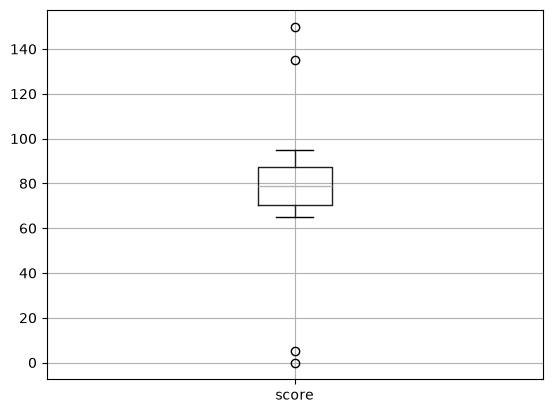

In [14]:
# boxplot으로 탐색하여 확인할 수 도 있다
import matplotlib.pyplot as plt
df.boxplot()
plt.show()

2) Z-score
- Z-score는 평균에서 얼마나 떨어져 있는지를 표준편차 기준으로 나타낸 값이다.
- 이상치를 판별할 때 IQR 방식은 중앙값을 중심으로 한 사분위수(Q1, Q3)를 이용하기 때문에 극단적인 값의 영향을 상대적으로 적게 받는다.
- 반면 Z-score는 평균과 표준편차를 이용하기 때문에 이상치가 평균과 표준편차 자체에 영향을 줄 수 있다. 특히 극단값이 포함되면 평균과 표준편차가 함께 변하면서 이상치 판별 결과에도 영향을 줄 수 있다.

- 따라서 Z-score를 이용한 이상치 판별에서는 데이터의 크기뿐만 아니라 데이터의 분포와 정규성 여부, 극단값의 존재 여부 등을 함께 고려하는 것이 중요하다.
- Z-score 내 점수와 평균이 같으면 0, 내 점수가 표준편차 만큼 떨어져 있으면 -1 또는 +1
- Z-score = (점수-평균) / 표준편차
- 일반적으로 |Z-score| > 3을 이상치로 판단하는 기준을 많이 사용한다.



In [16]:
# Scikit-learn으로 Z-score 계산
from scipy.stats import zscore

# 데이터가 작거나 값의 분포에 따라 값이 큰 경우에도 Z-score가 3보다 작게 나올 수도 있다. 
# 예제에서는 데이터 값을 조금 더 극단적으로 만들어 Z-score > 3을 명확하게 보여주는 것이 좋다.

data = {
    "시험점수": [
        65, 70, 72, 75, 78,
        80, 82, 85, 88, 95, 200
    ]
}

df = pd.DataFrame(data)

df["z_score"] = zscore(df["시험점수"])

print(df)

print("이상치:")

outlier = df[abs(df["z_score"]) > 3]
print(outlier)

    시험점수   z_score
0     65 -0.699866
1     70 -0.559893
2     72 -0.503903
3     75 -0.419919
4     78 -0.335936
5     80 -0.279946
6     82 -0.223957
7     85 -0.139973
8     88 -0.055989
9     95  0.139973
10   200  3.079409
이상치:
    시험점수   z_score
10   200  3.079409


2. 이상치 처리 <br>
이상치를 처리하는 세 가지 처리 방법 <br>

① 삭제 (Deletion): 이상치를 데이터셋에서 제외합니다. 단, 데이터 손실이 발생하므로 신중해야 합니다. <br>
② 대체 (Replacement): 이상치를 앞서 계산한 하한값이나 상한값으로 강제 조정하여 데이터의 범위를 제한합니다. <br>
③ 변환 (Transformation): 자연로그를 취하는 로그 변환(Log Transform) 등을 통해 데이터의 변동성을 줄입니다. <br>
앞서 다룬 결측치의 방법과 유사하다

결측치 → 평균, 중앙값, 최빈값, 예측값 등 <br>
이상치 → 하한값, 상한값 등으로 제한하는 방법이 있음

3.이상치 처리 실습
- 수집된 데이터 셋

In [17]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# 차트에 한글 깨지지 않도록 차트 폰트변경
plt.rcParams['font.family'] = 'Malgun Gothic'
# 차트에 "-"문자 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [18]:
# 1. 데이터 준비
scores = [60, 62, 65, 67, 68, 70, 72, 75, 78, 95, 200]

scores_np = np.array(scores)
scores_series = pd.Series(scores)

In [19]:
# 2. IQR 방법
print("===== IQR 방법 =====")

# 중앙값
median = scores_series.median()

# Q1, Q3
Q1 = scores_series.quantile(0.25)
Q3 = scores_series.quantile(0.75)

# IQR
IQR = Q3 - Q1

# 이상치 기준
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 최소값, 최대값
minimum = scores_series.min()
maximum = scores_series.max()

print("중앙값:", median)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("하한:", lower)
print("상한:", upper)
print("최소값:", minimum)
print("최대값:", maximum)

===== IQR 방법 =====
중앙값: 70.0
Q1: 66.0
Q3: 76.5
IQR: 10.5
하한: 50.25
상한: 92.25
최소값: 60
최대값: 200


In [20]:
# 이상치
outliers_iqr = scores_series[
    (scores_series < lower) | (scores_series > upper)
]

print("IQR 이상치:")
print(outliers_iqr)

IQR 이상치:
9      95
10    200
dtype: int64


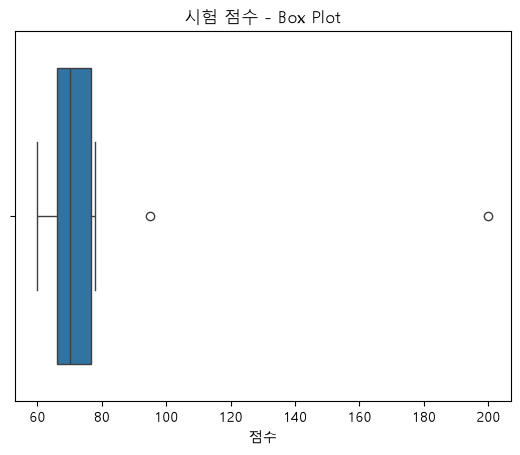

In [21]:
# 3. 박스플롯
fig = plt.figure()

axes1 = fig.add_subplot(1, 1, 1)

sns.boxplot(x=scores_series, ax=axes1)

axes1.set_title("시험 점수 - Box Plot")
axes1.set_xlabel("점수")

plt.show()

In [22]:
# 4. Z-score 방법
print()
print("===== Z-score 방법 =====")

# 기술 통계량은 같은 데이터를 사용해도 NumPy 배열과 Pandas Series는 제공하는 기능과 기본값에 차이가 있다.
# NumPy는 주로 모집단을 기준으로 하고, Pandas는 표본을 기준으로 한다.

# 평균
mean = scores_np.mean()

# 분산
variance = scores_np.var()

# 표준편차
std = scores_np.std()

print("평균:", round(mean, 2))
print("분산:", round(variance, 2))
print("표준편차:", round(std, 2))

# Z-score 계산
z_scores = (scores_np - mean) / std

print("Z-score:")
print(np.round(z_scores, 2))


===== Z-score 방법 =====
평균: 82.91
분산: 1453.36
표준편차: 38.12
Z-score:
[-0.6  -0.55 -0.47 -0.42 -0.39 -0.34 -0.29 -0.21 -0.13  0.32  3.07]


In [23]:
# 5. Z-score 이상치 판단
outliers_z = scores_np[np.abs(z_scores) > 3]

print("Z-score 이상치:")
print(outliers_z)

Z-score 이상치:
[200]


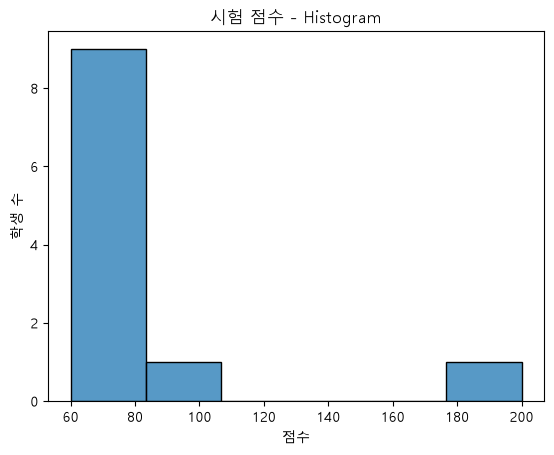

In [24]:
# 6. 히스토그램
fig = plt.figure()

axes1 = fig.add_subplot(1, 1, 1)

sns.histplot(scores_series, bins=6, ax=axes1)

axes1.set_title("시험 점수 - Histogram")
axes1.set_xlabel("점수")
axes1.set_ylabel("학생 수")

plt.show()

In [ ]:
# 과제: 200이라는 이상치 값을 제거 후 다시 2가지 방법으로 이상치 판별 진행
scores_series = scores_series[scores_series != 200]
print("200 제거 후 데이터:")
print(scores_series)

200 제거 후 데이터:
0    60
1    62
2    65
3    67
4    68
5    70
6    72
7    75
8    78
9    95
dtype: int64


33) DataFrame 다루기 - 데이터 구조(행·열)변경 피벗 메서드

- 판다스 피벗 관련 메서드 <br>
melt → 열 이름을 행으로 바꾼다 <br>
pivot → 값을 가로로 펼치기 <br>
pivot_table → 가로로 펼치면서 집계 <br>
stack → 열을 행 인덱스로 -> MultiIndex를 가진 Series가 된다 <br>
unstack → 멀티행 인덱스 하나를 열로(MultiIndex에서 사용)

1) melt
- 열이 너무 많이 펼쳐져 있어서 분석하기 불편한 데이터를, 한 가지 기준의 열 구조로 세로로(행으로) 정리할 때
- melt()는 하나의 대상에 대해 여러 열로 나뉘어 있는 측정값을, 변수와 값이라는 세로 구조로 정리할 때 사용한다.

In [29]:
import pandas as pd

# 데이터 준비
df = pd.DataFrame({
    "이름": ["철수", "영희"],
    "국어": [80, 90],
    "영어": [70, 95],
    "수학": [90, 85]
})

display(df)

,이름,국어,영어,수학
0,철수,80,70,90
1,영희,90,95,85


국어·영어·수학을 하나의 "과목"열로(값으로) 모으고, 각각의 점수를 "점수"열로(값으로) 모은다.

In [28]:
df_melt = df.melt(
    id_vars="이름",       # 그대로 유지할 열, 이름은 각 행의 대상을 구분하기 위해 그대로 놔둔다
    var_name="과목",      # 기존 열 이름을 저장할 열
    value_name="점수"     # 기존 열의 값을 저장할 열
)

display(df_melt)

,이름,과목,점수
0,철수,국어,80
1,영희,국어,90
2,철수,영어,70
3,영희,영어,95
4,철수,수학,90
5,영희,수학,85


In [30]:
# 데이터 준비
df = pd.DataFrame({
    "상품": ["노트북", "모니터", "키보드"],
    "1월": [100, 80, 50],
    "2월": [120, 90, 60],
    "3월": [150, 100, 70]
})

display(df)

,상품,1월,2월,3월
0,노트북,100,120,150
1,모니터,80,90,100
2,키보드,50,60,70


In [31]:
df_melt = df.melt(
    id_vars="상품",
    var_name="월",
    value_name="매출"
)

display(df_melt)

,상품,월,매출
0,노트북,1월,100
1,모니터,1월,80
2,키보드,1월,50
3,노트북,2월,120
4,모니터,2월,90
5,키보드,2월,60
6,노트북,3월,150
7,모니터,3월,100
8,키보드,3월,70


2) pivot

- melt()에서 변경된 데이터를 다시 보기 편하게 세로로 내려놓은 데이터를 다시 펼치기

In [32]:
import pandas as pd

# 데이터 준비
df = pd.DataFrame({
    "이름": ["철수", "철수", "철수", "영희", "영희", "영희"],
    "과목": ["국어", "영어", "수학", "국어", "영어", "수학"],
    "점수": [80, 70, 90, 90, 95, 85]
})

display(df)

,이름,과목,점수
0,철수,국어,80
1,철수,영어,70
2,철수,수학,90
3,영희,국어,90
4,영희,영어,95
5,영희,수학,85


In [33]:
df_pivot = df.pivot(
    index="이름",      # 행으로 사용할 열 -> 
    columns="과목",    # 새로운 열이 될 열 -> 과목열의 값들을 열이름으로
    values="점수"      # 실제 데이터 -> 새로 생성된 열의 값에 사용
)

display(df_pivot)

과목,국어,수학,영어
이름,,,
영희,90,85,95
철수,80,90,70


- pivot()의 index="이름"에서 이름은 원래 DataFrame의 열(column)이다. pivot()을 실행한 결과에서는 그 열이 행 인덱스(index)로 바뀐다. -> "이름"열은 행 인덱스가 된다.
- columns="과목"은 과목열의 값들을 인덱스별 열이를으로 변경한다. -> 이때 인덱스별 과목이름이 중복되면 error  ex) 인덱스 "철수"의 "국어"과목이 두번이상 발견되면 error
- values="점수"는  columns="과목"에서 추가된 열의 값들을 연결

In [34]:
# 만약 "이름" 인덱스를 열로 변경하고 새로운 인덱스를 추가하고 싶으면
result = df_pivot.reset_index()
display(result)

과목,이름,국어,수학,영어
0,영희,90,85,95
1,철수,80,90,70


3) pivot_table

- 중복 데이터가 있으면 계산해서 하나로 만들기
- 중복 데이터가 없다면 pivot, pivot_table은 동일하다. 둘의 차이는 "중복 데이터 처리 여부" 이다.
- pivot_table은 aggfunc만 바꾸면 다른 통계량으로 변경할 수 있다


In [37]:
import pandas as pd

# 데이터 준비
df = pd.DataFrame({
    "이름": ["철수", "철수", "철수", "철수", "영희", "영희", "영희"],
    "과목": ["국어", "국어", "영어", "수학", "국어", "영어", "수학"],
    "점수": [80, 50, 70, 90, 90, 95, 85]
})

display(df)

,이름,과목,점수
0,철수,국어,80
1,철수,국어,50
2,철수,영어,70
3,철수,수학,90
4,영희,국어,90
5,영희,영어,95
6,영희,수학,85


In [38]:
# error -> 철수의 국어값이 80, 50 두객의 값이 되어 에러발생 
df_pivot = df.pivot_table(
    index="이름",      # 행으로 사용할 열
    columns="과목",    # 새로운 열이 될 열
    values="점수",      # 실제 데이터
    aggfunc="mean"     # 중복되는 값들에 사용될 집계함수
)

display(df_pivot)

과목,국어,수학,영어
이름,,,
영희,90.0,85.0,95.0
철수,65.0,90.0,70.0


4) stack, unstack

- stack : 열을 행 인덱스로
- unstack : 행 인덱스를 열로

In [41]:
import pandas as pd

df = pd.DataFrame({
    "국어": [80, 90],
    "영어": [70, 95]
}, index=["철수", "영희"])

display(df)

,국어,영어
철수,80,70
영희,90,95


In [42]:
result = df.stack()
display(result)

print(type(result))

철수  국어    80
    영어    70
영희  국어    90
    영어    95
dtype: int64

<class 'pandas.Series'>


In [43]:
result2 = result.unstack()
display(result2)

,국어,영어
철수,80,70
영희,90,95


34) DataFrame 다루기 - groupby() 메서드

- groupby()는 특정 열의 같은 값끼리 그룹을 만든 후, 그룹별로 평균·합계·개수 등을 계산할 때 사용한다.
- SQL의 GROUP BY와 거의 같은 개념이다.

In [44]:
import pandas as pd

df = pd.DataFrame({
    "부서": ["영업", "영업", "개발", "개발", "인사"],
    "이름": ["철수", "영희", "민수", "지수", "길동"],
    "매출": [100, 150, 200, 250, 120]
})

display(df)

,부서,이름,매출
0,영업,철수,100
1,영업,영희,150
2,개발,민수,200
3,개발,지수,250
4,인사,길동,120


In [45]:
result = df.groupby("부서")["매출"].mean()

display(result)

부서
개발    225.0
영업    125.0
인사    120.0
Name: 매출, dtype: float64

In [46]:
# 부서별 매출 합계
display(df.groupby("부서")["매출"].sum())

# 부서별 매출 평균
display(df.groupby("부서")["매출"].mean())

# 부서별 데이터 개수
display(df.groupby("부서")["매출"].count())

# 부서별 최대 매출
display(df.groupby("부서")["매출"].max())

# 부서별 최소 매출
display(df.groupby("부서")["매출"].min())

부서
개발    450
영업    250
인사    120
Name: 매출, dtype: int64

부서
개발    225.0
영업    125.0
인사    120.0
Name: 매출, dtype: float64

부서
개발    2
영업    2
인사    1
Name: 매출, dtype: int64

부서
개발    250
영업    150
인사    120
Name: 매출, dtype: int64

부서
개발    200
영업    100
인사    120
Name: 매출, dtype: int64

- groupby(), transform() 메서드를 이용하여 범주형 파생변수 추가 예

In [47]:
import pandas as pd

df = pd.DataFrame({
    "부서": ["영업", "영업", "개발", "개발", "인사"],
    "이름": ["철수", "영희", "민수", "지수", "길동"],
    "매출": [100, 150, 200, 250, 120]
})

display(df)

,부서,이름,매출
0,영업,철수,100
1,영업,영희,150
2,개발,민수,200
3,개발,지수,250
4,인사,길동,120


- groupby().mean()은 그룹별로 하나의 결과만 반환하지만, transform("mean")은 원래 행 개수와 동일하게 결과를 반환한다.



In [ ]:
df.groupby("부서")["매출"].transform("mean")
print(df["부서평균매출"])

0    125.0
1    125.0
2    225.0
3    225.0
4    120.0
Name: 부서평균매출, dtype: float64


In [55]:
df["부서평균매출"] = df.groupby("부서")["매출"].transform("mean") 
print(df["부서평균매출"])

0    125.0
1    125.0
2    225.0
3    225.0
4    120.0
Name: 부서평균매출, dtype: float64
